# Phase 2 — RFM Analysis

## Objective
Calculate RFM (Recency, Frequency, Monetary) values for each customer
and segment them based on their purchasing behavior.

## What is RFM?
- **Recency (R):** How recently a customer made a purchase
- **Frequency (F):** How many times a customer made a purchase
- **Monetary (M):** How much total money a customer spent

---

## 2.1 Import Libraries

## 2.2 Load Cleaned Dataset

## 2.3 Calculate RFM Values
- **Recency** — Gap between last purchase date and reference date
- **Frequency** — Count of unique invoices per customer
- **Monetary** — Sum of TotalPrice per customer

## 2.4 RFM Scoring
- Score each R, F, M value on a scale of 1 to 5
- Higher score = better customer behavior

## 2.5 Customer Segmentation
- Combine RFM scores to create segments
- Classify customers — Champions, Loyal, At Risk, Lost etc.

## 2.6 Segment Analysis
- Count of customers per segment
- Average RFM values per segment

## 2.7 Export RFM Data
- Save final RFM segmented data as CSV for Power BI and MySQL


## What is RFM?
- **Recency (R):** How recently a customer made a purchase
- **Frequency (F):** How many times a customer made a purchase
- **Monetary (M):** How much total money a customer spent

## 2.1 Import Libraries

In [1]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2.2 Load Cleaned Dataset


In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\project2\Dataset\rfm_cleaned.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [8]:
df.shape

(392692, 10)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  str    
 2   Description  392692 non-null  str    
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  str    
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  int64  
 7   Country      392692 non-null  str    
 8   TotalPrice   392692 non-null  float64
 9   YearMonth    392692 non-null  str    
dtypes: float64(2), int64(3), str(5)
memory usage: 30.0 MB


*- Cleaned dataset loaded successfully. 392,692 rows, 9 columns. Ready for RFM calculation.*

## 2.3 Calculate RFM Values

- **Recency** — Gap between last purchase date and reference date
- **Frequency** — Count of unique invoices per customer
- **Monetary** — Sum of TotalPrice per customer

## Recency

**2.3.1 Recency**
- Recency = Number of days since customer's last purchase
- We use InvoiceDate with max() to find the most recent purchase per customer
- Lower recency value means customer purchased more recently = better

In [4]:
reference_date = df['InvoiceDate'].max()
print('Date use for referencing:', reference_date)

Date use for referencing: 2011-12-09 12:50:00


In [5]:
rfm = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
rfm.columns = ['CustomerID', 'LastPurchaseDate']
rfm.head()

,CustomerID,LastPurchaseDate
0,12346,2011-01-18 10:01:00
1,12347,2011-12-07 15:52:00
2,12348,2011-09-25 13:13:00
3,12349,2011-11-21 09:51:00
4,12350,2011-02-02 16:01:00


In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max()
rfm['LastPurchaseDate'] = pd.to_datetime(rfm['LastPurchaseDate'])

rfm['Recency'] = (reference_date - rfm['LastPurchaseDate']).dt.days
rfm.head()

,CustomerID,LastPurchaseDate,Recency
0,12346,2011-01-18 10:01:00,325
1,12347,2011-12-07 15:52:00,1
2,12348,2011-09-25 13:13:00,74
3,12349,2011-11-21 09:51:00,18
4,12350,2011-02-02 16:01:00,309


**Recency Calculated Successfully.**
- Recency = Number of days between customer's last purchase and reference date (2011-12-09)
- Lower recency value = more recent customer = better
- Higher recency value = customer has not purchased in a long time

## Frequency

**2.3.2 Frequency**
- Frequency = Count of unique invoices per customer
- We use InvoiceNo with nunique() to count each order only once
- Higher frequency means customer is more engaged with the store

In [7]:
rfm['Frequency'] = df.groupby('CustomerID')['InvoiceNo'].nunique().values
rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency
0,12346,2011-01-18 10:01:00,325,1
1,12347,2011-12-07 15:52:00,1,7
2,12348,2011-09-25 13:13:00,74,4
3,12349,2011-11-21 09:51:00,18,1
4,12350,2011-02-02 16:01:00,309,1


**Frequency Calculated Successfully.**
- Frequency = Number of unique orders placed by each customer
- Higher frequency value = customer visits and purchases more often
- nunique() used on InvoiceNo to avoid counting duplicate rows of same invoice

## Monetary

**2.3.3 Monetary**
- Monetary = Total amount spent by each customer
- We use TotalPrice with sum() to calculate total revenue per customer
- Higher monetary value means customer generates more revenue for the business

In [8]:
rfm['Monetary'] = df.groupby('CustomerID')['TotalPrice'].sum().values
rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,325,1,77183.60
1,12347,2011-12-07 15:52:00,1,7,4310.00
2,12348,2011-09-25 13:13:00,74,4,1797.24
3,12349,2011-11-21 09:51:00,18,1,1757.55
4,12350,2011-02-02 16:01:00,309,1,334.40


**Monetary Calculated Successfully.**
- Monetary = Total revenue generated by each customer
- Calculated using sum of TotalPrice grouped by CustomerID
- Higher monetary value = higher value customer for the business

In [9]:
rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,325,1,77183.60
1,12347,2011-12-07 15:52:00,1,7,4310.00
2,12348,2011-09-25 13:13:00,74,4,1797.24
3,12349,2011-11-21 09:51:00,18,1,1757.55
4,12350,2011-02-02 16:01:00,309,1,334.40


## 2.4 RFM Scoring

- Each RFM value is scored on a scale of 1 to 5
- 5 = Best, 1 = Worst
- Customers are divided into 5 equal groups (quintiles) using pd.qcut()
- Recency is scored in reverse — lower days = higher score
- Frequency and Monetary are scored normally — higher value = higher score

**Recency**

**2.4.1 Recency Score (R_Score)**
- Scoring Recency on a scale of 1 to 5
- Lower recency days = more recent customer = higher score
- Score 5 = purchased very recently, Score 1 = purchased long time ago|

In [10]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])

In [11]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
print(pd.qcut(rfm['Recency'], q=5).value_counts().sort_index())

Recency
(-0.001, 12.4]    868
(12.4, 32.0]      904
(32.0, 71.0]      858
(71.0, 178.0]     843
(178.0, 373.0]    865
Name: count, dtype: int64


**Recency Score assigned successfully.**
- Customers with lowest recency days received Score 5
- Customers with highest recency days received Score 1

**Frequency**

**2.4.2 Frequency Score (F_Score)**
- Scoring Frequency on a scale of 1 to 5
- Higher frequency = more orders placed = higher score
- Score 5 = most frequent customer, Score 1 = least frequent customer

In [12]:
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])

In [13]:
print(pd.qcut(rfm['Frequency'].rank(method='first'), q=5).value_counts().sort_index())

Frequency
(0.999, 868.4]      868
(868.4, 1735.8]     867
(1735.8, 2603.2]    868
(2603.2, 3470.6]    867
(3470.6, 4338.0]    868
Name: count, dtype: int64


**Frequency Score assigned successfully.**
- Customers with highest number of orders received Score 5
- Customers with lowest number of orders received Score 1

**Monetary**

**2.4.3 Monetary Score (M_Score)**
- Scoring Monetary on a scale of 1 to 5
- Higher monetary value = more revenue generated = higher score
- Score 5 = highest spending customer, Score 1 = lowest spending customer

In [14]:
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

In [15]:
print(pd.qcut(rfm['Monetary'].rank(method='first'), q=5).value_counts().sort_index())

Monetary
(0.999, 868.4]      868
(868.4, 1735.8]     867
(1735.8, 2603.2]    868
(2603.2, 3470.6]    867
(3470.6, 4338.0]    868
Name: count, dtype: int64


**Monetary Score assigned successfully.**
- Customers with highest total spend received Score 5
- Customers with lowest total spend received Score 1

In [16]:
rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,2011-01-18 10:01:00,325,1,77183.60,1,1,5
1,12347,2011-12-07 15:52:00,1,7,4310.00,5,5,5
2,12348,2011-09-25 13:13:00,74,4,1797.24,2,4,4
3,12349,2011-11-21 09:51:00,18,1,1757.55,4,1,4
4,12350,2011-02-02 16:01:00,309,1,334.40,1,1,2


## 2.5 Customer Segmentation

- Now we combine R, F, M scores into a single RFM Score
- RFM Score is a 3 digit combination of R, F, M scores
- Example: Customer with R=5, F=5, M=5 gets RFM Score = 555 (best customer)
- Example: Customer with R=1, F=1, M=1 gets RFM Score = 111 (worst customer)
- Based on RFM Score we will assign customer segments like Champions, Loyal, At Risk etc.

In [17]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,2011-01-18 10:01:00,325,1,77183.60,1,1,5,115
1,12347,2011-12-07 15:52:00,1,7,4310.00,5,5,5,555
2,12348,2011-09-25 13:13:00,74,4,1797.24,2,4,4,244
3,12349,2011-11-21 09:51:00,18,1,1757.55,4,1,4,414
4,12350,2011-02-02 16:01:00,309,1,334.40,1,1,2,112


### **Customer Segmentation**

**2.5.1 Assigning Customer Segments**
- Segments are assigned based on combination of R, F, M scores
- Each segment represents a distinct customer behavior pattern
- Business can target each segment with different marketing strategies

In [25]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r == 5 and f == 5:
        return 'Champion'
    elif f >= 4 and r >= 3:
        return 'Loyal'
    elif r >= 4 and f < 4:
        return 'Potential Loyal'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif m == 5:
        return 'Big Spender'
    elif r == 1 and f == 1:
        return 'Lost'
    elif f == 2:
        if r >= 3:
            return 'Potential Loyal'
        else:
            return 'At Risk'
    elif f == 1:
        if r >= 3:
            return 'Potential Loyal'
        else:
            return 'Lost'
    elif r == 3 and f == 3:
        return 'Loyal'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm.head(10)

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,2011-01-18 10:01:00,325,1,77183.60,1,1,5,115,Big Spender
1,12347,2011-12-07 15:52:00,1,7,4310.00,5,5,5,555,Champion
2,12348,2011-09-25 13:13:00,74,4,1797.24,2,4,4,244,At Risk
3,12349,2011-11-21 09:51:00,18,1,1757.55,4,1,4,414,Potential Loyal
4,12350,2011-02-02 16:01:00,309,1,334.40,1,1,2,112,Lost
5,12352,2011-11-03 14:37:00,35,8,2506.04,3,5,5,355,Loyal
6,12353,2011-05-19 17:47:00,203,1,89.00,1,1,1,111,Lost
7,12354,2011-04-21 13:11:00,231,1,1079.40,1,1,4,114,Lost
8,12355,2011-05-09 13:49:00,213,1,459.40,1,1,2,112,Lost
9,12356,2011-11-17 08:40:00,22,3,2811.43,4,3,5,435,Potential Loyal


**Customer Segments Assigned Successfully.**
- Each customer is now classified into a meaningful business segment
- These segments will drive marketing and retention strategy

In [26]:
print(rfm['Segment'].value_counts())

Segment
Loyal              1194
At Risk            1137
Potential Loyal     977
Lost                556
Champion            439
Big Spender          35
Name: count, dtype: int64


### Customer Segmentation — Final Distribution

RFM scores were mapped to business segments using a priority-based rule engine 
(highest-value segments checked first, broader recency/frequency bands last, 
with no residual "Others" bucket).

| Segment | Count | % of Customers | Business Meaning |
|---|---|---|---|
| Loyal | 1194 | 27.5% | Frequent, reliable buyers with decent spend |
| At Risk | 1137 | 26.2% | Previously active, recency has dropped — needs win-back |
| Potential Loyal | 977 | 22.5% | Recent buyers with low frequency — needs nurturing |
| Lost | 556 | 12.8% | Long inactive, low frequency — low-priority reactivation |
| Champion | 439 | 10.1% | Recent, frequent, high spend — retain and reward |
| Big Spender | 35 | 0.8% | High monetary value outliers — VIP/white-glove treatment |

**Key observation:** Loyal and At Risk together make up over half the customer base 
(~54%), consistent with the UCI Online Retail dataset's known pattern of a large 
repeat-buyer core alongside a significant declining-engagement group. Big Spender 
is intentionally a narrow, high-priority segment (M_Score = 5, not already captured 
by a higher-priority rule) representing high-value outliers who warrant individual 
retention attention despite low volume.

## Phase 2: RFM Scoring & Customer Segmentation — Complete

Customers were scored on Recency, Frequency, and Monetary value using quintile-based 
scoring (`pd.qcut()`), with Recency reversed (lower recency = higher score, since 
recent activity is desirable). Combined R-F-M scores were then mapped to business 
segments using a priority-ordered rule engine, ensuring full coverage with no 
unclassified ("Others") customers remaining.

**Final Segment Distribution:**

| Segment | Count | % of Customers |
|---|---|---|
| Loyal | 1194 | 27.5% |
| At Risk | 1137 | 26.2% |
| Potential Loyal | 977 | 22.5% |
| Lost | 556 | 12.8% |
| Champion | 439 | 10.1% |
| Big Spender | 35 | 0.8% |

**Segment Definitions:**
- **Champion** — Recent, frequent, high spend. Reward and retain.
- **Loyal** — Frequent, reliable buyers with decent spend.
- **Potential Loyal** — Recent buyers, low frequency. Needs nurturing/engagement.
- **At Risk** — Previously active, recency dropping. Needs win-back campaign.
- **Lost** — Long inactive, low frequency. Low-priority reactivation.
- **Big Spender** — High monetary value outliers regardless of pattern. VIP handling.

---

## Phase 3: Exploratory Visualization

The next step validates the segmentation logic visually — checking whether segments 
are behaviorally distinct (not just score-distinct) and identifying patterns to 
support business recommendations.



The following visuals will be built to validate the segmentation logic and 
support business recommendations:

1. **Segment Distribution (Bar Chart)**  
   Shows customer count per segment. Confirms where the customer base is 
   concentrated.

2. **Monetary vs Frequency Scatterplot (colored by Segment)**  
   Shows how well segments cluster or overlap when plotted against real 
   purchase behavior. Tests the visual separation quality of the segmentation.

3. **Heatmap — Average R/F/M Score per Segment**  
   Summarizes each segment's average R, F, M score as a single reference 
   table. Confirms each segment has a distinct scoring signature.

Each visual will be followed by a written observation summarizing the pattern 
and its business implication. A consolidated business recommendations section 
will follow once all four visuals are complete.## Phase 3: Exploratory Visualization Plan


### Segment Distribution (Bar Chart)

C:\Users\HP\AppData\Local\Temp\ipykernel_14924\2577752313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=order, palette='viridis')


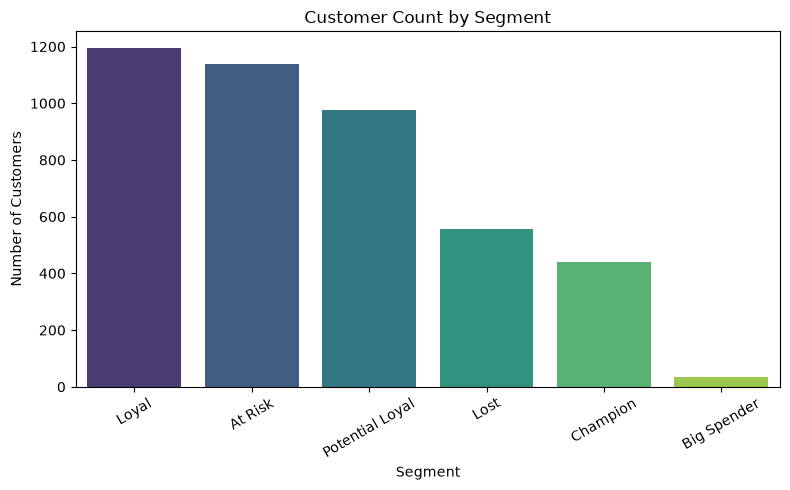

In [27]:
plt.figure(figsize=(8,5))
order = rfm['Segment'].value_counts().index
sns.countplot(data=rfm, x='Segment', order=order, palette='viridis')
plt.title('Customer Count by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** Loyal (1194) and At Risk (1137) are the two largest segments, 
together making up over half the customer base. Potential Loyal (977) is the 
third largest, followed by Lost (556), Champion (439), and Big Spender (35). 
This distribution suggests a large "movable middle" — customers who are neither 
clearly high-value nor lost — representing the biggest opportunity for targeted 
retention campaigns.

**Observation:** Segments show significant overlap when plotted by Frequency vs 
Monetary, particularly in the low-frequency range where most customers 
(one-time or occasional buyers) are concentrated. This is expected behavior for 
rule-based RFM segmentation, which prioritizes business interpretability over 
statistical cluster separation. Segments are distinguished more by their 
Recency behavior (not shown on this axis) than by Frequency/Monetary alone, 
explaining the visual overlap. A K-Means clustering approach could produce 
tighter, more separated clusters at the cost of interpretability.

### Monetary vs Frequency Scatterplot (colored by Segment)

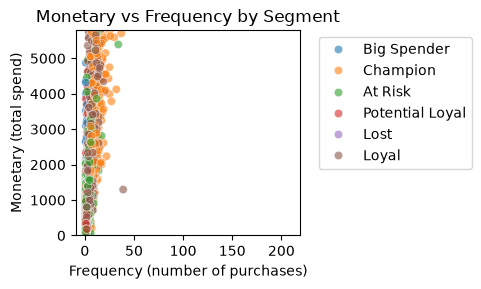

In [32]:
plt.figure(figsize=(5,3))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment', 
                 palette='tab10', alpha=0.6)
plt.title('Monetary vs Frequency by Segment')
plt.xlabel('Frequency (number of purchases)')
plt.ylabel('Monetary (total spend)')
plt.ylim(0, rfm['Monetary'].quantile(0.95))
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation:** Segments show significant overlap when plotted by Frequency vs 
Monetary, particularly in the low-frequency range (0–50 purchases) where nearly 
all customers are concentrated. This is expected behavior for rule-based RFM 
segmentation, which prioritizes business interpretability over statistical 
cluster separation. Segments are distinguished more by their Recency behavior 
(not shown on this axis) than by Frequency/Monetary alone, which explains the 
visual overlap. A clustering approach (e.g., K-Means) could produce tighter, 
more separated groups at the cost of interpretability.

### Heatmap — Average R/F/M Score per Segment

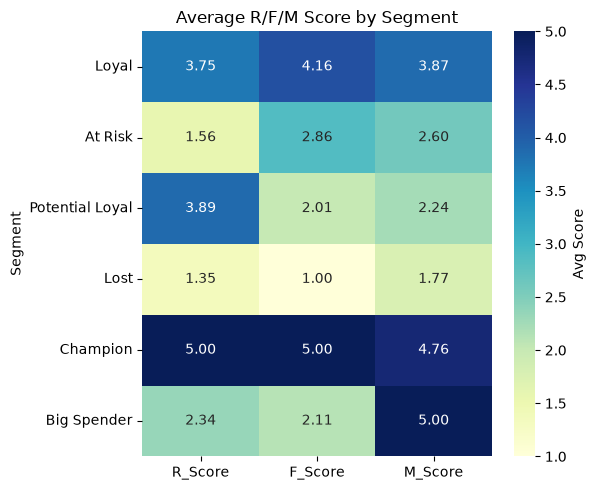

In [35]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

segment_avg = rfm.groupby('Segment')[['R_Score','F_Score','M_Score']].mean().loc[order]

plt.figure(figsize=(6,5))
sns.heatmap(segment_avg, annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label':'Avg Score'})
plt.title('Average R/F/M Score by Segment')
plt.tight_layout()
plt.show()

**Observation:** Each segment shows a distinct and logically consistent R/F/M 
score signature. Champion scores near-maximum across all three dimensions, 
confirming correct identification of top-tier customers. Big Spender shows a 
uniquely high Monetary score (5.0) despite mid-range Recency and Frequency, 
correctly isolating high-value outliers regardless of purchase pattern. 
Potential Loyal shows high Recency but low Frequency (newer/returning 
customers), while At Risk shows the inverse (previously active, now 
disengaged). Lost scores lowest across all three dimensions, as expected. 
This confirms the rule-based segmentation logic produces behaviorally coherent 
segments, despite the visual overlap observed in the Frequency-Monetary 
scatterplot.

## Business Recommendations

Based on the RFM segmentation and visual analysis, the following actions are 
recommended for each customer segment:

1. **Champion (439 customers, 10.1%)** — Near-perfect R/F/M scores across the 
   board. Reward with loyalty perks, early access to new products, and referral 
   incentives to maximize retention and advocacy.

2. **Big Spender (35 customers, 0.8%)** — High monetary value despite lower 
   recency/frequency. Assign to a VIP/white-glove retention program with 
   personalized outreach — small in volume but high revenue risk if lost.

3. **Loyal (1194 customers, 27.5%)** — Consistently solid across all metrics. 
   Maintain engagement through regular communication and moderate incentives 
   to prevent drift toward "At Risk."

4. **Potential Loyal (977 customers, 22.5%)** — Recent but low-frequency 
   buyers. Nurture with onboarding campaigns, second-purchase discounts, and 
   product recommendations to build purchase frequency.

5. **At Risk (1137 customers, 26.2%)** — Previously active, recency has 
   dropped. This is the largest actionable segment — prioritize win-back 
   campaigns (targeted discounts, re-engagement emails) since Monetary/
   Frequency history shows they were previously valuable.

6. **Lost (556 customers, 12.8%)** — Long inactive, low frequency and spend. 
   Lowest priority for active investment; consider low-cost automated 
   reactivation campaigns only, or exclude from marketing spend to focus 
   budget on At Risk and Potential Loyal.

**Key strategic insight:** Loyal and At Risk together represent over half the 
customer base (53.7%). Since At Risk customers show meaningfully higher 
Frequency and Monetary scores than Lost customers, win-back campaigns targeting 
this segment likely offer the highest ROI of any single intervention — 
converting even a fraction of At Risk back to Loyal would have outsized 
revenue impact given the segment's size.

In [36]:
rfm.to_csv('rfm_customer_segmented.csv', index = False)